# Inspecting a Spatiotemporal Dataset: PeakWeather

>
> The notebook adapts the PeakWeather [demo](https://github.com/MeteoSwiss/PeakWeather/blob/main/docs/source/examples/peakweather_demo.ipynb).
>



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/...)

This notebook explores a real-world example of spatiotemporal dataset, [PeakWeather](https://peakweather.readthedocs.io/latest/), with a focus on practical inspection and preparation workflows. 
The data is collected from about 300 meteorological stations distributed across Switzerland.

<img src="https://raw.githubusercontent.com/MeteoSwiss/PeakWeather/main/docs/source/_static/stations.png" alt="Stations" width="350"/>


## Setup the environment
### Install the packages

The cell below installs the required packages: PyTorch, PyTorch Geometric, and the PeakWeather dataset library.
If you are running locally with `uv`, these should already be available from `pyproject.toml`.

In [ ]:
%pip -q install "torch>=2.5,<2.6" "torchvision>=0.20,<0.21" "torchaudio>=2.5,<2.6"
%pip -q install "torch-geometric>=2.7.0"
%pip -q install "peakweather @ git+https://github.com/MeteoSwiss/PeakWeather@main"

### Verify the environment


Check that all packages are correctly installed and their versions.

In [1]:
import torch
import torch_geometric
import peakweather

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch_geometric:", torch_geometric.__version__)
print("peakweather:",  peakweather.__version__)

/Users/daniele.zambon/postdoc/gdl4stts-unipd/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.5.1
cuda available: False
torch_geometric: 2.7.0
peakweather: 0.2.1


## PeakWeather dataset

### Loading the data

`PeakWeatherDataset` is the main entry point for the dataset.
By default, it downloads the raw data into the current working directory on first use and reads from cache on subsequent calls.

Here we load data for the years 2024–2025 at the default **10-minute** temporal resolution.

In [2]:
from peakweather import PeakWeatherDataset
print(PeakWeatherDataset.__doc__)

PeakWeather is a high-quality meteorological dataset derived from `SwissMetNet
    <https://www.meteoswiss.admin.ch/weather/measurement-systems/land-based-stations/automatic-measurement-network.html>`_,
    the automated measurement network operated by MeteoSwiss. It offers a robust
    resource for research and applications in spatiotemporal modeling.

    PeakWeather includes high-frequency meteorological observations recorded every
    10 minutes, collected from 302 ground stations distributed across Switzerland,
    covering the period from January 1st, 2017 to October 13th, 2025. The dataset also
    provides high-resolution topographic features at 50-meter resolution and ensemble
    forecasts from the ICON-CH1-EPS operational numerical weather prediction (NWP)
    model. The dataset is described in more details in `"PeakWeather: MeteoSwiss
    Weather Station Measurements for Spatiotemporal Deep Learning"
    <https://arxiv.org/abs/2506.13652>`_ (Zambon et al., 2025).

    This 

In [3]:
dataset = PeakWeatherDataset(years=[2024,2025])
print(dataset)

PeakWeatherDataset(num_time_steps=93888, num_stations=299, num_parameters=8)


With `get_observations` you can load the timeseries data as a dataframe or array.

In [4]:
df = dataset.get_observations(
    stations=["ABO", "GRO", "KLO"],  # list of stations
    parameters=["temperature", "wind_speed", "humidity"],  # list of weather parameters
    first_date="2024-08-02 16:32",
    last_date="2024-08-06 23:26",
)

df.head(5)

nat_abbr                          ABO                               GRO  \
name                      temperature wind_speed   humidity temperature   
datetime                                                                  
2024-08-02 16:40:00+00:00   19.400000        2.0  67.000000   24.100000   
2024-08-02 16:50:00+00:00   19.600000        2.7  67.300003   23.100000   
2024-08-02 17:00:00+00:00   19.200001        2.0  71.199997   22.900000   
2024-08-02 17:10:00+00:00   19.000000        0.9  73.900002   23.000000   
2024-08-02 17:20:00+00:00   19.100000        1.5  71.099998   22.799999   

nat_abbr                                                KLO             \
name                      wind_speed   humidity temperature wind_speed   
datetime                                                                 
2024-08-02 16:40:00+00:00        0.8  72.500000   26.299999        2.8   
2024-08-02 16:50:00+00:00        0.9  79.099998   25.500000        3.2   
2024-08-02 17:00:00+00:00        1.4  80.800003   25.400000        2.7   
2024-08-02 17:10:00+00:00        2.3  78.300003   25.200001        2.7   
2024-08-02 17:20:00+00:00        2.3  78.199997   25.000000        2.3   

nat_abbr                              
name                        humidity  
datetime                              
2024-08-02 16:40:00+00:00  50.000000  
2024-08-02 16:50:00+00:00  56.200001  
2024-08-02 17:00:00+00:00  55.799999  
2024-08-02 17:10:00+00:00  57.000000  
2024-08-02 17:20:00+00:00  58.000000

### Visualization of the data


In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib

def plot_weather_parameters(df, stations, parameters):
    fig, ax = plt.subplots(len(parameters), figsize=(12, 7))

    time_freq = mdates.date2num(df.index[1]) - mdates.date2num(df.index[0])
    time_freq_minutes = int(time_freq * 24 * 60)
    
    colors = matplotlib.colormaps["tab10"]

    for i, param in enumerate(parameters):
        for station in stations:
            ax[i].plot(
                df.index,
                df[station, param],
                label=f"{station} {param}",
                color=colors(stations.index(station)),
            )
        ax[i].set_title(f"{param.capitalize()} ({time_freq_minutes} min)")
        ax[i].set_ylabel(f"{param.capitalize()} ({dataset.parameters_table['unit'][param]})")
        ax[i].legend()
        ax[i].grid(True)

    plt.tight_layout()
    plt.show()

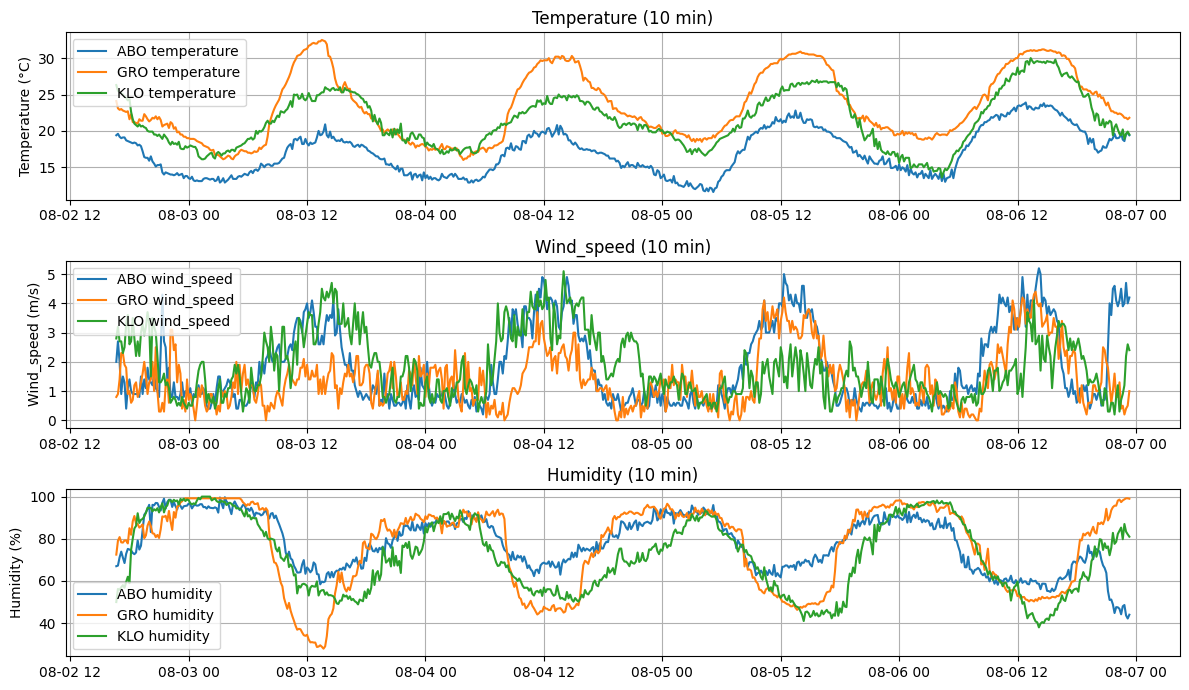

In [6]:
plot_weather_parameters(df, stations=["ABO", "GRO", "KLO"], parameters=["temperature", "wind_speed", "humidity"])

### Temporal re-sampling

We can initialize the dataset to resample the time series to a coarser frequency, such as from the default **10-minute** interval to **hourly**. 
This is useful for reducing the variability of highly dynamic parameters like wind speed, aligning with lower temporal resolutions, or shortening sequence length for training.

Hourly data also allows us comparing with the forecasts from the numerical weather prediction (NWP) model, which are provided as hourly forecasts within PeakWeather.

Each parameter has a default aggregation method used during temporal resampling, which can be overridden using the `aggregation_method` parameter.

In [7]:
dataset = PeakWeatherDataset(
    freq="h",
    years = [2024, 2025],
    aggregation_methods={"temperature": "mean", "wind_gust": "max"},
    station_type="meteo_station",
)

print(dataset)

PeakWeatherDataset(num_time_steps=15649, num_stations=158, num_parameters=8)


Just like before, let's look that temperature and wind speed for the stations of *Adelboden*, *Grono* and *Kloten*, this time with an hourly temporal resolution.

In [8]:
df = dataset.get_observations(
    stations=["ABO", "GRO", "KLO"],
    parameters=["temperature", "wind_speed", "humidity"],
    first_date="2024-08-02 16:32",
    last_date="2024-08-06 23:26",
)

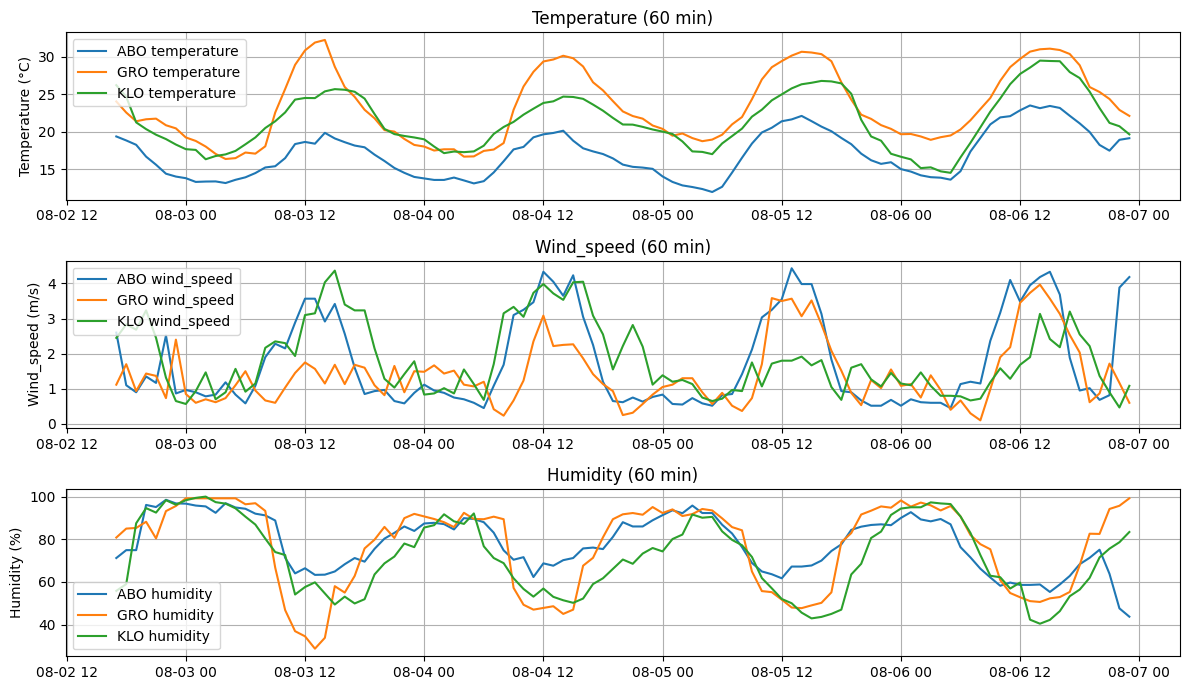

In [9]:
plot_weather_parameters(df, stations=["ABO", "GRO", "KLO"], parameters=["temperature", "wind_speed", "humidity"])

### Static attributes

Each station is either a `rain_gauge`, which measures precipitation (and sometimes temperature), or a `meteo_station` station, which records multiple weather parameters. Every station has a known geographic location, an elevation above sea level, and additional static attributes derived from topographic data interpolated to its position.

The full topographic features at a $50m$ resolution can be loaded by initializing the `PeakWeatherDataset` dataset with the `extended_topo_vars` parameter.

In [10]:
dataset.stations_table

,station_name,latitude,longitude,station_height,swiss_easting,swiss_northing,ASPECT_2000M_SIGRATIO1,WE_DERIVATIVE_2000M_SIGRATIO1,TPI_2000M,SN_DERIVATIVE_10000M_SIGRATIO1,dem,SN_DERIVATIVE_2000M_SIGRATIO1,SLOPE_10000M_SIGRATIO1,ASPECT_10000M_SIGRATIO1,SLOPE_2000M_SIGRATIO1,STD_2000M,STD_10000M,TPI_10000M,WE_DERIVATIVE_10000M_SIGRATIO1,station_type
nat_abbr,,,,,,,,,,,,,,,,,,,,
ABO,Adelboden,46.491703,7.560703,1321.38,2.609372e+06,1.148939e+06,124.863129,-0.167379,-53.303345,-0.026807,1317.771851,0.116605,1.702339,25.582031,11.529667,120.940262,374.830623,-443.723877,-0.012833,meteo_station
AEG,Oberägeri,47.133636,8.608206,724.43,2.688729e+06,1.220956e+06,190.899567,0.010865,-20.030273,-0.013760,724.173462,0.056423,1.099379,315.811829,3.288559,27.269887,141.396220,-165.792114,0.013376,meteo_station
AIG,Aigle,46.326647,6.924472,381.02,2.560403e+06,1.130714e+06,301.137115,0.002014,-0.256348,0.006587,381.100006,-0.001216,0.760270,119.760574,0.134786,0.000000,287.689425,-195.166718,-0.011520,meteo_station
ALT,Altdorf,46.887069,8.621894,437.86,2.690181e+06,1.193563e+06,240.803589,0.020179,-2.120819,-0.009294,438.587494,0.011276,0.995863,57.677086,1.324231,0.000000,493.449619,-518.464722,-0.014689,meteo_station
AND,Andeer,46.610139,9.431981,987.10,2.752692e+06,1.164037e+06,285.070679,0.079193,-57.052063,-0.033264,984.354675,-0.021324,2.702750,314.800964,4.688558,71.570846,459.982181,-745.938782,0.033496,meteo_station
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VLS,Vals,46.627758,9.188711,1242.00,2.734017e+06,1.165551e+06,259.876007,0.230579,-221.533813,-0.030685,1248.217163,0.041172,2.499389,314.665771,13.182495,191.950111,420.127457,-795.717529,0.031045,meteo_station
WAE,Wädenswil,47.220958,8.677706,485.37,2.693848e+06,1.230744e+06,30.840942,-0.056398,1.528931,-0.030955,487.379700,-0.094456,2.063067,30.759644,6.277975,57.277290,109.597974,-32.960632,-0.018423,meteo_station
WFJ,Weissfluhjoch,46.833325,9.806394,2691.24,2.780616e+06,1.189634e+06,102.749420,-0.120945,118.755859,-0.005864,2675.146729,0.027366,2.487068,82.240639,7.068717,84.781556,291.512251,602.742188,-0.043037,meteo_station


### Missing data

Weather-station records are rarely perfectly complete, so it is useful to inspect the gaps before building forecasting datasets.

In this section, we keep missing observations explicit by preserving them as `NaN` values, then we count how many values are missing.

In [11]:
dataset = PeakWeatherDataset(
    freq="h",
    years = [2024, 2025],
    aggregation_methods={"temperature": "mean", "wind_gust": "max"},
    station_type="meteo_station",
    pad_missing_values=True,
    imputation_method=None,
)

df, mask = dataset.get_observations(
    stations=["ABO", "GRO", "KLO"],
    parameters=["temperature", "wind_speed", "humidity"],
    return_mask=True,
)

In [12]:
print("Missing observations per station and parameter:")
print()
print(df.isna().sum())

print()
print()
print("Missing data in percentage:")
print()
print(df.isna().sum()/len(df) * 100)


Missing observations per station and parameter:

nat_abbr  name       
ABO       temperature     0
          wind_speed     16
          humidity        0
GRO       temperature     0
          wind_speed     90
          humidity        0
KLO       temperature     0
          wind_speed      0
          humidity        0
dtype: int64


Missing data in percentage:

nat_abbr  name       
ABO       temperature    0.000000
          wind_speed     0.102243
          humidity       0.000000
GRO       temperature    0.000000
          wind_speed     0.575117
          humidity       0.000000
KLO       temperature    0.000000
          wind_speed     0.000000
          humidity       0.000000
dtype: float64


It is common to store information about missing observations through a boolean **mask** of the same shape of the data.

- A value of `True` indicates that the observation is **valid** (i.e., not missing).
- A value of `False` indicates a **missing** observation.

This is useful because missing data are often imputed, instead of keeping them as NaN values. The mask is used to evaluate the model only on actual data.

In [13]:
print("Number of `False` values (i.e., missing observations) per station and parameter:")
print()
print((~mask).sum())

mask.head()


Number of `False` values (i.e., missing observations) per station and parameter:

nat_abbr  name       
ABO       temperature     0
          wind_speed     16
          humidity        0
GRO       temperature     0
          wind_speed     90
          humidity        0
KLO       temperature     0
          wind_speed      0
          humidity        0
dtype: int64


nat_abbr                          ABO                             GRO  \
name                      temperature wind_speed humidity temperature   
datetime                                                                
2024-01-01 00:00:00+00:00        True       True     True        True   
2024-01-01 01:00:00+00:00        True       True     True        True   
2024-01-01 02:00:00+00:00        True       True     True        True   
2024-01-01 03:00:00+00:00        True       True     True        True   
2024-01-01 04:00:00+00:00        True       True     True        True   

nat_abbr                                              KLO                      
name                      wind_speed humidity temperature wind_speed humidity  
datetime                                                                       
2024-01-01 00:00:00+00:00       True     True        True       True     True  
2024-01-01 01:00:00+00:00       True     True        True       True     True  
2024-01-01 02:00:00+00:00       True     True        True       True     True  
2024-01-01 03:00:00+00:00       True     True        True       True     True  
2024-01-01 04:00:00+00:00       True     True        True       True     True

## Temperature forecasting

Let's load the temperature data first.

In [14]:
dataset = PeakWeatherDataset(
    freq="h",
    years = [2023, 2024, 2025],
    station_type="meteo_station",
    parameters=["temperature"],
)


### Time series windowing

The `get_windows` function extracts sliding windows from the time series using a look-back window `w` and forecast horizon `h`.
This prepares the data in a format that's easy to use with framework-specific datasets and data loaders (e.g., PyTorch, TensorFlow, JAX).

This returns arrays of shape `[t, w, n, f]` for the inputs `x` and `[t, h, n, f]` for the outputs `y`, where `t` is the number of windows, `n` is the number of stations (nodes) and `f` is the number of features.




The `get_windows` function extracts sliding windows from the time series using a look-back window `w` and forecast horizon `h`.  
This prepares the data in a format that can be passed directly to framework-specific datasets and data loaders such as PyTorch, TensorFlow, or JAX.

For each sample, the method returns:

- `x` with shape `[t, w, n, f]`: the input window
- `y` with shape `[t, h, n, f]`: the prediction target

where:

- `t` is the number of extracted windows
- `w` is the number of past time steps
- `h` is the number of future time steps
- `n` is the number of stations (nodes)
- `f` is the number of features

A single sliding window can be visualized as:

| Past context (model input) | Prediction target |
|---|---|
| `x[:, 0] ... x[:, w-1]` | `y[:, 0] ... y[:, h-1]` |


As the window moves forward in time, this procedure generates many supervised training examples from a single multivariate time series.

In [15]:
window = 12
horizon = 9

pw_windows = dataset.get_windows(
    window_size=window,
    horizon_size=horizon,
)

# [num_windows, num_time_steps, num_stations, num_parameters]
print(f"Windows x type: \t{type(pw_windows.x)}")
print(f"Windows x shape: \t{pw_windows.x.shape}")
print(f"Windows mask_x shape: \t{pw_windows.mask_x.shape}")
print(f"Windows y shape: \t{pw_windows.y.shape}")
print(f"Windows mask_y shape: \t{pw_windows.mask_y.shape}")

Windows x type: 	<class 'numpy.ndarray'>
Windows x shape: 	(24389, 12, 150, 1)
Windows mask_x shape: 	(24389, 12, 150, 1)
Windows y shape: 	(24389, 9, 150, 1)
Windows mask_y shape: 	(24389, 9, 150, 1)


In [16]:
win_idx = 214

print("Input window indices (timestamps):")
print(pw_windows.index_x[win_idx])

print()
print("Target window indices (timestamps):")
print(pw_windows.index_y[win_idx])


Input window indices (timestamps):
[Timestamp('2023-01-09 22:00:00+0000', tz='UTC')
 Timestamp('2023-01-09 23:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 00:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 01:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 02:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 03:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 04:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 05:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 06:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 07:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 08:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 09:00:00+0000', tz='UTC')]

Target window indices (timestamps):
[Timestamp('2023-01-10 10:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 11:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 12:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 13:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 14:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 15:00:00+0000', tz='UTC')
 Timestamp('2023-01-10 16:00:00+0000', tz='UT

In [17]:
print()
print(" Input: from", pw_windows.index_x[win_idx][0], "to", pw_windows.index_x[win_idx][-1])
print("Target: from", pw_windows.index_y[win_idx][0], "to", pw_windows.index_y[win_idx][-1])

print()
print(" Next input: from", pw_windows.index_x[win_idx][0], "to", pw_windows.index_x[win_idx][-1])
print("Next target: from", pw_windows.index_y[win_idx][0], "to", pw_windows.index_y[win_idx][-1])


 Input: from 2023-01-09 22:00:00+00:00 to 2023-01-10 09:00:00+00:00
Target: from 2023-01-10 10:00:00+00:00 to 2023-01-10 18:00:00+00:00

 Next input: from 2023-01-09 22:00:00+00:00 to 2023-01-10 09:00:00+00:00
Next target: from 2023-01-10 10:00:00+00:00 to 2023-01-10 18:00:00+00:00


Now we build a Torch dataset and data loaders.

The dataset is split chronologically into **train**, **validation**, and **test** sets. Each sample is a tuple `(x, y, mask)` where:

- `x` — input window of shape `[window_size, num_stations, num_features]`
- `y` — forecasting target of shape `[horizon_size, num_stations, num_features]`
- `mask` — boolean mask of the same shape as `y`, indicating valid (non-missing) observations

In [18]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset, TensorDataset


# Build supervised windows directly from PeakWeather API.
batch_size = 64

# x: [num_windows, window, num_stations, num_parameters]
# y: [num_windows, horizon, num_stations, num_parameters]
x = torch.as_tensor(pw_windows.x, dtype=torch.float32)
y = torch.as_tensor(pw_windows.y, dtype=torch.float32)
mask = torch.as_tensor(pw_windows.mask_y, dtype=torch.float32)

dataset_torch = TensorDataset(x, y, mask)  # include mask for later use in loss function

n_samples = len(dataset_torch)
train_end = int(0.7 * n_samples)
val_end = int(0.85 * n_samples)

train_ds = Subset(dataset_torch, list(range(0, train_end)))
val_ds = Subset(dataset_torch, list(range(train_end, val_end)))
test_ds = Subset(dataset_torch, list(range(val_end, n_samples)))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# # for compatibility with later prints/model init
# series = x

num_nodes = x.shape[2]
print("          num nodes:", num_nodes)
print("   look-back window:", window)
print("forecasting horizon:", horizon)
print(".    dataset length:", n_samples)
print("     missing values:", int((1-mask).mean() * 100) , "%")
print("    example x shape:", dataset_torch[0][0].shape)
print("    example y shape:", dataset_torch[0][1].shape)
print(" example mask shape:", dataset_torch[0][2].shape)


          num nodes: 150
   look-back window: 12
forecasting horizon: 9
.    dataset length: 24389
     missing values: 0 %
    example x shape: torch.Size([12, 150, 1])
    example y shape: torch.Size([9, 150, 1])
 example mask shape: torch.Size([9, 150, 1])


/var/folders/m6/8jqkbmgx1_s2hm1kbnzhjpyh0000gp/T/ipykernel_97469/1258784670.py:11: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:212.)
  x = torch.as_tensor(pw_windows.x, dtype=torch.float32)


## Time Series Forecasting

We start by designing a simple recurrent neural network (RNN) baseline that processes each station time series independently and predicts the future horizon from the input window.

In [19]:
import torch.nn as nn
from einops import rearrange


class SimpleRNNForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1, num_layers=1):
        super().__init__()
        # Shared RNN weights are applied independently to each station series.
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, horizon * output_size)

    def forward(self, x):
        # treat each station series as a separate sequence in the batch dimension
        x_ = rearrange(x, "b w n f -> (b n) w f") 

        rnn_states, _ = self.rnn(x_)
        # [(b*n) hidden_size] <- [(b*n) w hidden_size]
        rnn_state_last = rnn_states[:, -1]        

        y_hat = self.head(rnn_state_last)
        # [(b*n) hidden_size] <- [(b*n) w hidden_size]
        batch_size = x.size(0)
        y_hat = rearrange(y_hat, "(b n) (h f) -> b h n f", b=batch_size, h=horizon)

        return y_hat


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleRNNForecaster(
    input_size=x.shape[-1],
    hidden_size=32, 
    output_size=y.shape[-1],
    num_layers=1).to(device)

print("device:", device)
model

device: cpu


SimpleRNNForecaster(
  (rnn): RNN(1, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=9, bias=True)
)

## Train it

We now train the `SimpleRNNForecaster` using mini-batches from the chronological train/validation split.  
Optimization is performed with **Adam**, while the prediction error is minimized with **Mean Squared Error (MSE)** over the forecast horizon.  
At each epoch, we compute both training and validation loss to monitor convergence.

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

def masked_mae_loss(y, y_hat, mask):
    assert mask.dtype == torch.float32
    absolute_errors = torch.abs(y - y_hat)
    absolute_errors = absolute_errors * mask
    return absolute_errors.sum() / mask.sum()

def run_epoch(loader, model, training=True):

    model.train(training)
    total_loss = 0.0
    total_count = 0

    for x, y, mask in loader:
        x = x.to(device).float()  # [B, W, N, 1]
        y = y.to(device).float()  # [B, N, 1]

        if training:
            optimizer.zero_grad()

        y_hat = model(x)
        assert y_hat.shape == y.shape, f"y_hat.shape {y_hat.shape} y.shape {y.shape}"
        loss = masked_mae_loss(y_hat, y, mask)

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_count += x.size(0)

    return total_loss / total_count

history = {"train": [], "val": []}

for epoch in range(1, 15):
    train_loss = run_epoch(train_loader, model=model, training=True)
    val_loss = run_epoch(val_loader, model=model, training=False)

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    # if epoch % 10 == 0 or epoch == 1:
    print(f"Epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f}")

Epoch 001 | train 3.5832 | val 2.1853
Epoch 002 | train 2.2191 | val 2.0133
Epoch 003 | train 2.0422 | val 2.0248
Epoch 004 | train 1.9668 | val 1.9426
Epoch 005 | train 1.9118 | val 1.8765
Epoch 006 | train 1.8744 | val 1.8638
Epoch 007 | train 1.8815 | val 2.0497
Epoch 008 | train 1.8816 | val 1.9168
Epoch 009 | train 1.8877 | val 2.0395
Epoch 010 | train 1.8944 | val 1.8680
Epoch 011 | train 1.8483 | val 1.8553
Epoch 012 | train 1.8307 | val 1.8357
Epoch 013 | train 1.8185 | val 1.8415
Epoch 014 | train 1.8118 | val 1.8366


## Plot the learning curve

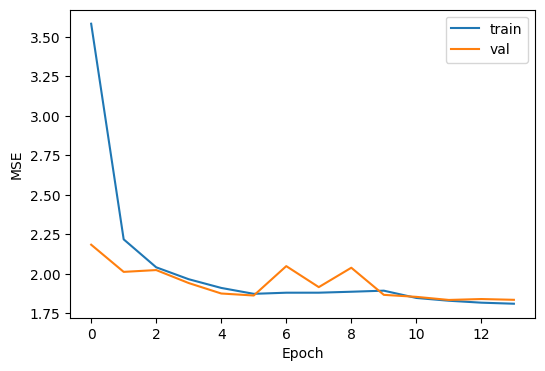

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

## Inspect one prediction

tensor(17.1333)


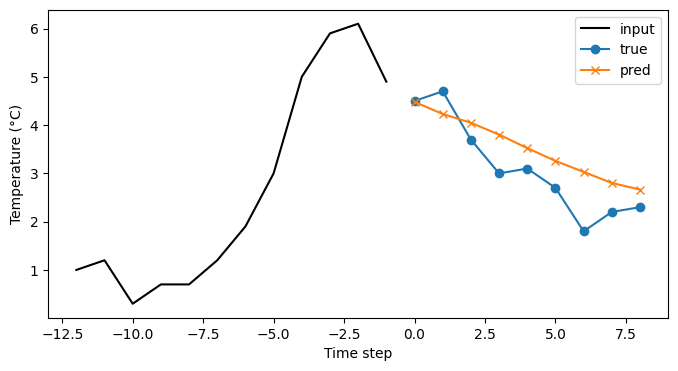

(24389, 12, 150, 1)
(24389, 9, 150, 1)
torch.Size([1, 9, 150, 1])


In [23]:
win_id = int(torch.randint(pw_windows.x.shape[0], size=(1,)))
node_id = int(torch.randint(pw_windows.x.shape[1], size=(1,)))

with torch.no_grad():
    y_hat = model(torch.tensor(pw_windows.x[win_id: win_id+1]))

input_vals = pw_windows.x[win_id, :, node_id, 0]
true_vals = pw_windows.y[win_id, :, node_id, 0] 
pred_vals = y_hat[0, :, node_id, 0].cpu()
mask = pw_windows.mask_y[win_id, :, node_id, 0] 

print(y_hat.max())

if (1-mask).sum() > 0:
    print("Skip due to missing values")
else:
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(input_vals.shape[0]) - input_vals.shape[0], input_vals, "-k", label="input")
    plt.plot(true_vals, marker="o", label="true")
    plt.plot(pred_vals, marker="x", label="pred")
    # plt.plot(mask, ":", label="mask")
    plt.xlabel("Time step")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.show()

print(pw_windows.x.shape)
print(pw_windows.y.shape)
print(y_hat.shape)